In [2]:
# ============================================================
# Temporal Pattern Analysis
# Investigating how time of day and content category
# influence click-through behaviour on digital news platforms
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================================
# GOOGLE DRIVE SETUP
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Input file path
input_path = '/content/drive/MyDrive/Dissertation NewsCorp (26 July ddl)/dataset/dataset_final.csv'

# Output directory
output_dir = '/content/drive/MyDrive/Dissertation NewsCorp (26 July ddl)/phase 5 Temporal pattern analysis'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive


In [4]:
# ============================================================
# SECTION 1: DATA PREPROCESSING
# ============================================================

df = pd.read_csv(input_path)

print(f"Raw dataset size: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Keep only relevant columns
df = df[['user_id', 'timestamp', 'clicked', 'category', 'subcategory']].copy()

# Remove missing values
df = df.dropna().reset_index(drop=True)
df = df[~df['category'].isin(['northamerica', 'kids'])].reset_index(drop=True)
print(f"Dataset size after removing missing values: {df.shape[0]:,} rows")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract temporal features
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

print("\nSample of extracted temporal features:")
print(df[['timestamp', 'hour', 'day_of_week', 'clicked', 'category']].head())

Raw dataset size: 5,843,444 rows, 7 columns
Dataset size after removing missing values: 5,843,253 rows

Sample of extracted temporal features:
            timestamp  hour day_of_week  clicked category
0 2019-11-11 09:05:58     9      Monday        1   sports
1 2019-11-11 09:05:58     9      Monday        0     news
2 2019-11-12 18:11:30    18     Tuesday        0   sports
3 2019-11-12 18:11:30    18     Tuesday        0     news
4 2019-11-12 18:11:30    18     Tuesday        0    autos


In [5]:
# Now you can correctly get the min and max of the timestamp column
print(df['timestamp'].min())
print(df['timestamp'].max())

2019-11-09 00:00:19
2019-11-14 23:59:13


In [6]:
# ============================================================
# SECTION 2: TIME-OF-DAY GROUPING
# ============================================================

def assign_time_period(hour):
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 22:
        return 'Evening'
    else:
        return 'Night'

df['time_period'] = df['hour'].apply(assign_time_period)

# Define display order for time periods
time_period_order = ['Morning', 'Afternoon', 'Evening', 'Night']

print("\nTime period distribution:")
print(df['time_period'].value_counts()[time_period_order])


Time period distribution:
time_period
Morning      2526493
Afternoon    1853906
Evening       572228
Night         890626
Name: count, dtype: int64



Hourly CTR Table:
 hour  total  clicks      ctr
    0  39081    1541 0.039431
    1  46295    1816 0.039227
    2  72564    2840 0.039138
    3 124994    4806 0.038450
    4 215810    8315 0.038529
    5 341072   13469 0.039490
    6 404381   16582 0.041006
    7 415355   17473 0.042068
    8 438949   18835 0.042909
    9 375632   15830 0.042142
   10 446882   18617 0.041660
   11 445294   18832 0.042291
   12 432751   16932 0.039126
   13 409551   15572 0.038022
   14 335489   12885 0.038407
   15 238663    9501 0.039809
   16 234688    9373 0.039938
   17 202764    8024 0.039573
   18 170443    6780 0.039779
   19 136635    5403 0.039543
   20 113398    4502 0.039701
   21  88007    3755 0.042667
   22  63745    2715 0.042592
   23  50810    1942 0.038221

Time Period CTR Table:
time_period   total  clicks      ctr
    Morning 2526493  106169 0.042022
  Afternoon 1853906   72287 0.038992
    Evening  572228   23155 0.040465
      Night  890626   34729 0.038994


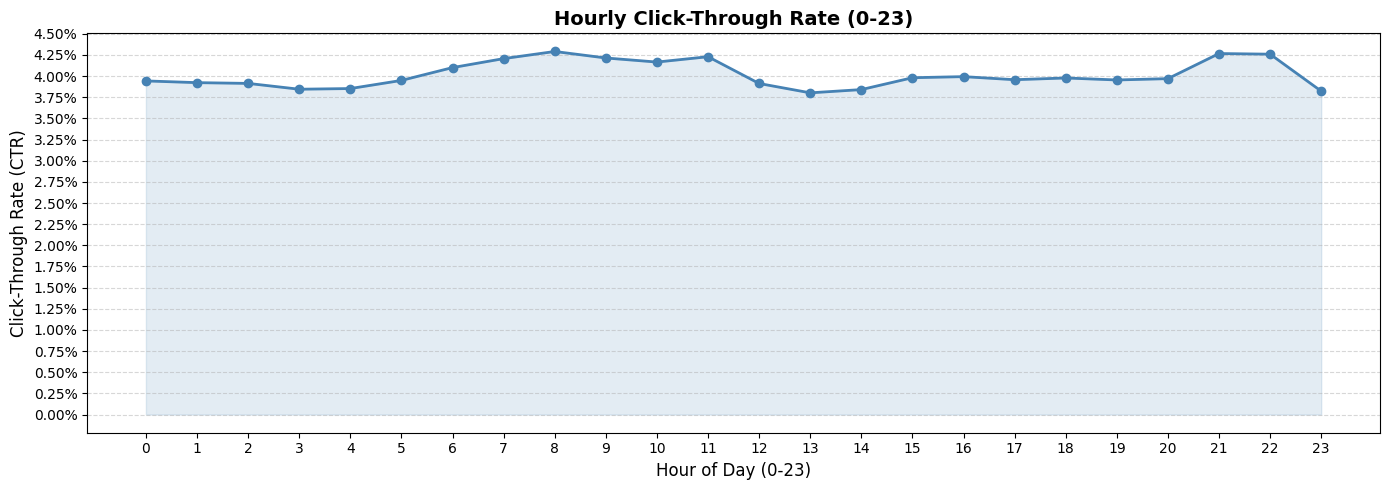

Saved: hourly_ctr_trend.png


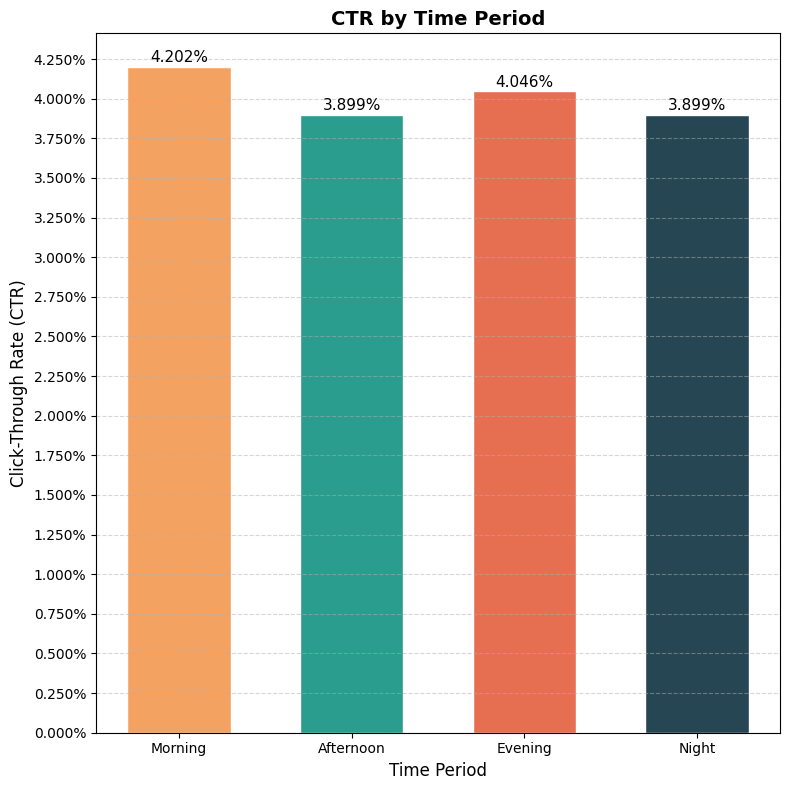

Saved: ctr_by_time_period.png


In [7]:
# ============================================================
# SECTION 3: CTR COMPARISON ACROSS TIME
# ============================================================

# --- Hourly CTR ---
hourly_ctr = (
    df.groupby('hour')['clicked']
    .agg(total='count', clicks='sum')
    .assign(ctr=lambda x: x['clicks'] / x['total'])
    .reset_index()
)

print("\nHourly CTR Table:")
print(hourly_ctr.to_string(index=False))

# --- Time Period CTR ---
period_ctr = (
    df.groupby('time_period')['clicked']
    .agg(total='count', clicks='sum')
    .assign(ctr=lambda x: x['clicks'] / x['total'])
    .reindex(time_period_order)
    .reset_index()
)

print("\nTime Period CTR Table:")
print(period_ctr.to_string(index=False))

# --- Visualisation: Hourly CTR Line Chart ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hourly_ctr['hour'], hourly_ctr['ctr'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(hourly_ctr['hour'], hourly_ctr['ctr'], alpha=0.15, color='steelblue')
ax.set_xlabel('Hour of Day (0-23)', fontsize=12)
ax.set_ylabel('Click-Through Rate (CTR)', fontsize=12)
ax.set_title('Hourly Click-Through Rate (0-23)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_locator(mtick.MultipleLocator(0.0025))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{output_dir}/hourly_ctr_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: hourly_ctr_trend.png")

# --- Visualisation: CTR by Time Period Bar Chart ---
colors = ['#f4a261', '#2a9d8f', '#e76f51', '#264653']
fig, ax = plt.subplots(figsize=(8, 8))
bars = ax.bar(period_ctr['time_period'], period_ctr['ctr'], color=colors, edgecolor='white', width=0.6)
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Click-Through Rate (CTR)', fontsize=12)
ax.set_title('CTR by Time Period', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=3))
ax.yaxis.set_major_locator(mtick.MultipleLocator(0.0025))
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, period_ctr['ctr']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0001,
            f'{val:.3%}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_dir}/ctr_by_time_period.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ctr_by_time_period.png")


Ranked Category × Time Period Engagement:
     category time_period  total  clicks      ctr
        music     Evening  23992    1802 0.075108
      weather   Afternoon  28417    1991 0.070064
      weather     Evening   9967     668 0.067021
           tv     Morning 102805    6620 0.064394
           tv       Night  26805    1670 0.062302
        music   Afternoon  90265    5462 0.060511
        music       Night  33719    2028 0.060144
           tv   Afternoon  93681    5317 0.056756
        music     Morning 121032    6696 0.055324
       sports     Evening  64062    3302 0.051544
       sports     Morning 241487   11945 0.049464
        video     Morning  37826    1828 0.048327
      weather       Night  10169     491 0.048284
         news     Morning 673140   31742 0.047155
        video     Evening  10800     497 0.046019
       sports   Afternoon 188153    8596 0.045686
        video       Night  14319     638 0.044556
         news       Night 277122   12267 0.044266
       

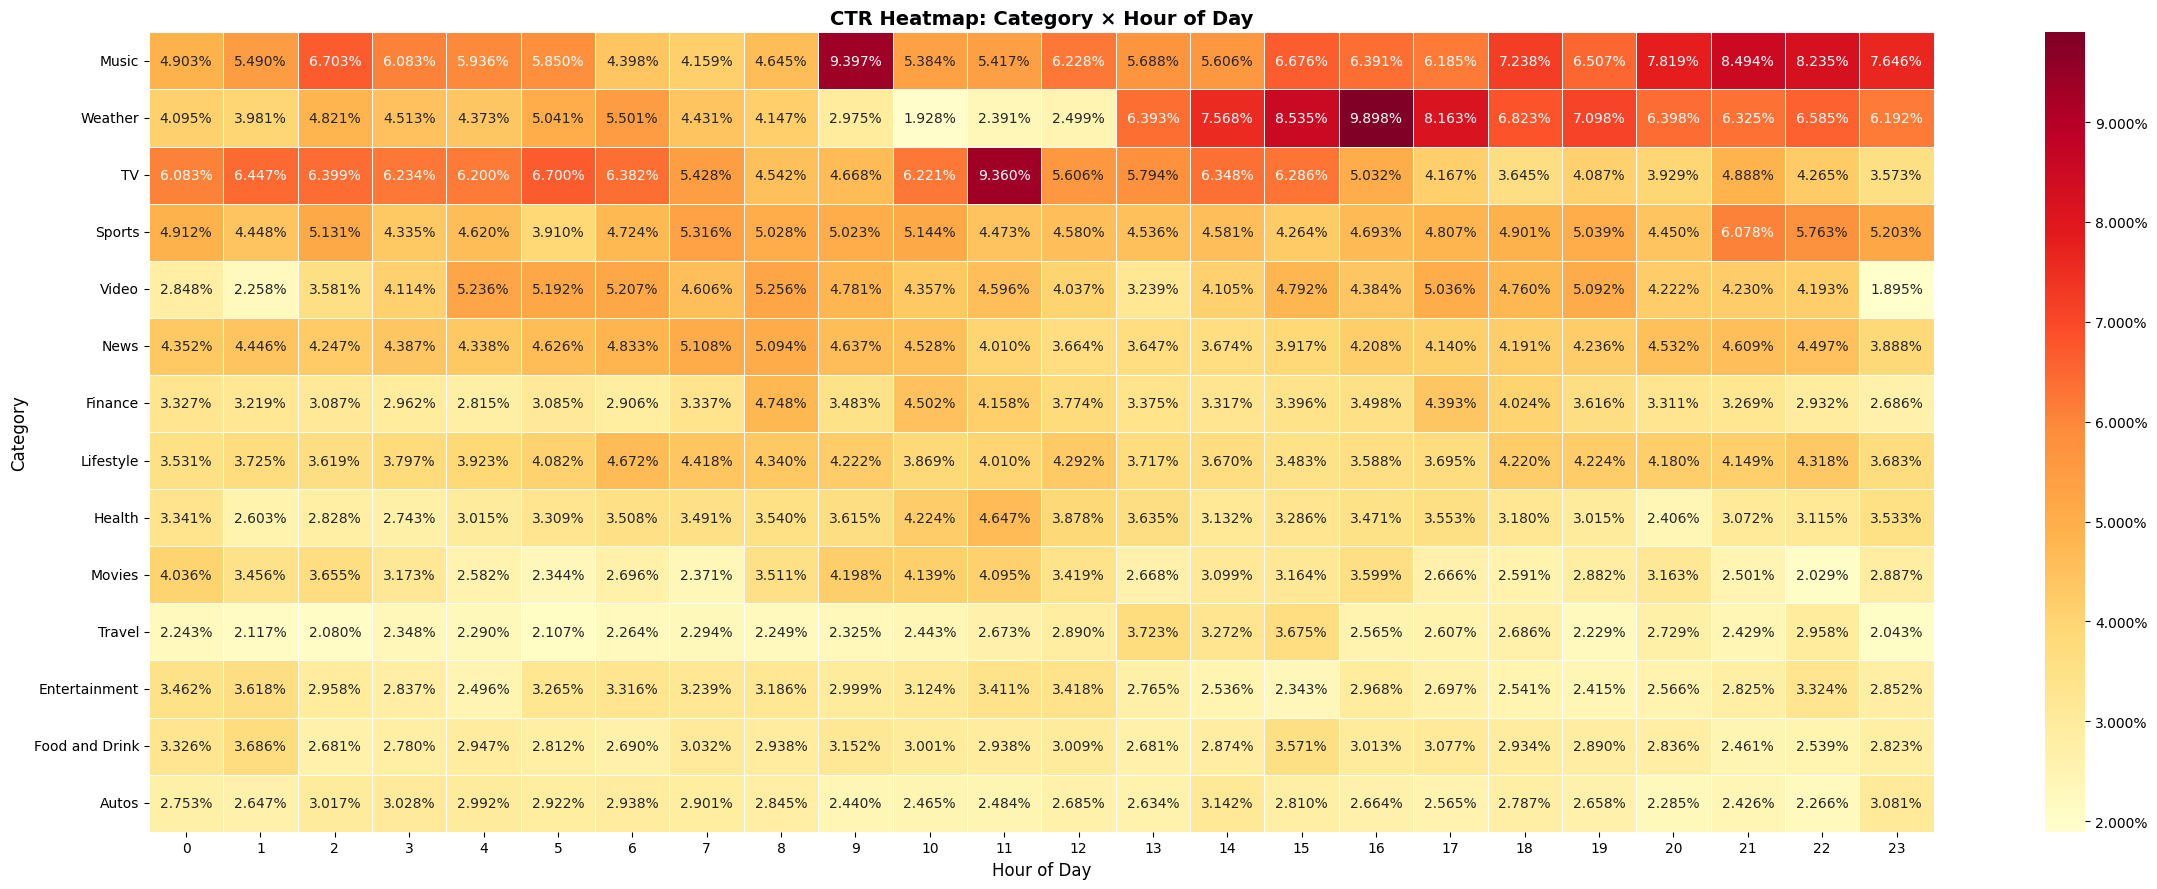

Saved: heatmap_category_hour.png


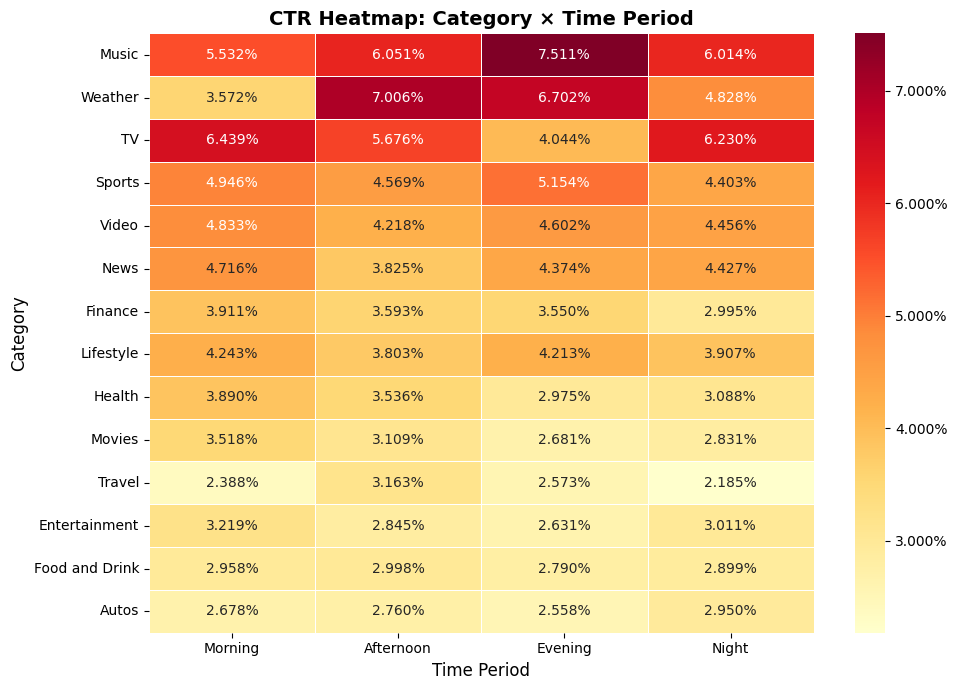

Saved: heatmap_category_time_period.png


In [8]:
# ============================================================
# SECTION 4: CATEGORY–TIME INTERACTION ANALYSIS
# ============================================================

# --- Category × Hour CTR ---
cat_hour_ctr = (
    df.groupby(['category', 'hour'])['clicked']
    .agg(total='count', clicks='sum')
    .assign(ctr=lambda x: x['clicks'] / x['total'])
    .reset_index()
)

# Pivot for heatmap
cat_hour_pivot = cat_hour_ctr.pivot(index='category', columns='hour', values='ctr')

# --- Category × Time Period CTR ---
cat_period_ctr = (
    df.groupby(['category', 'time_period'])['clicked']
    .agg(total='count', clicks='sum')
    .assign(ctr=lambda x: x['clicks'] / x['total'])
    .reset_index()
)

# Pivot for heatmap
cat_period_pivot = cat_period_ctr.pivot(
    index='category', columns='time_period', values='ctr'
)[time_period_order]

# --- Ranked Engagement Table ---
ranked_engagement = (
    cat_period_ctr.sort_values('ctr', ascending=False)
    .reset_index(drop=True)
)
print("\nRanked Category × Time Period Engagement:")
print(ranked_engagement.to_string(index=False))
mean_ctr = cat_period_pivot.mean().mean()

print(f"Mean CTR across Category × Time Period heatmap: {mean_ctr:.3%}")

# Categories to keep (desired order)
selected_categories = [
    'music',
    'weather',
    'tv',
    'sports',
    'video',
    'news',
    'finance',
    'lifestyle',
    'health',
    'movies',
    'travel',
    'entertainment',
    'foodanddrink',
    'autos'
]

# Filter heatmap data
cat_hour_pivot_filtered = cat_hour_pivot.loc[selected_categories]
cat_period_pivot_filtered = cat_period_pivot.loc[selected_categories]

# Better display names
display_names = [
    'Music',
    'Weather',
    'TV',
    'Sports',
    'Video',
    'News',
    'Finance',
    'Lifestyle',
    'Health',
    'Movies',
    'Travel',
    'Entertainment',
    'Food and Drink',
    'Autos'
]
# --- Heatmap: Category × Hour ---
fig, ax = plt.subplots(figsize=(24, 9))
sns.heatmap(
    cat_hour_pivot_filtered,
    annot=True,
    fmt='.3%',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'format': mtick.PercentFormatter(xmax=1.0, decimals=3)} )
ax.set_yticklabels(display_names, rotation=0)
ax.set_title('CTR Heatmap: Category × Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/heatmap_category_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heatmap_category_hour.png")


# --- Heatmap: Category × Time Period ---
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    cat_period_pivot_filtered,
    annot=True,
    fmt='.3%',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'format': mtick.PercentFormatter(xmax=1.0, decimals=3)}
)
ax.set_yticklabels(display_names, rotation=0)
ax.set_title('CTR Heatmap: Category × Time Period', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/heatmap_category_time_period.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heatmap_category_time_period.png")

In [9]:
# ============================================================
# SECTION 5: OPTIMAL PUBLISHING WINDOW ANALYSIS
# ============================================================

# Best hour per category
best_hour = (
    cat_hour_ctr.loc[cat_hour_ctr.groupby('category')['ctr'].idxmax()]
    [['category', 'hour', 'ctr']]
    .rename(columns={'hour': 'best_hour', 'ctr': 'best_hour_ctr'})
)

# Best time period per category
best_period = (
    cat_period_ctr.loc[cat_period_ctr.groupby('category')['ctr'].idxmax()]
    [['category', 'time_period', 'ctr']]
    .rename(columns={'time_period': 'best_time_period', 'ctr': 'best_period_ctr'})
)

# Merge into optimal publishing windows table
optimal_windows = best_hour.merge(best_period, on='category').sort_values(
    'best_hour_ctr', ascending=False
).reset_index(drop=True)

print("\nOptimal Publishing Windows by Category:")
print(optimal_windows.to_string(index=False))


Optimal Publishing Windows by Category:
     category  best_hour  best_hour_ctr best_time_period  best_period_ctr
      weather         16       0.098983        Afternoon         0.070064
        music          9       0.093968          Evening         0.075108
           tv         11       0.093598          Morning         0.064394
       sports         21       0.060776          Evening         0.051544
        video          8       0.052557          Morning         0.048327
         news          7       0.051076          Morning         0.047155
      finance          8       0.047482          Morning         0.039109
    lifestyle          6       0.046725          Morning         0.042435
       health         11       0.046474          Morning         0.038901
       movies          9       0.041980          Morning         0.035180
       travel         13       0.037226        Afternoon         0.031633
 foodanddrink          1       0.036857        Afternoon         0.0299

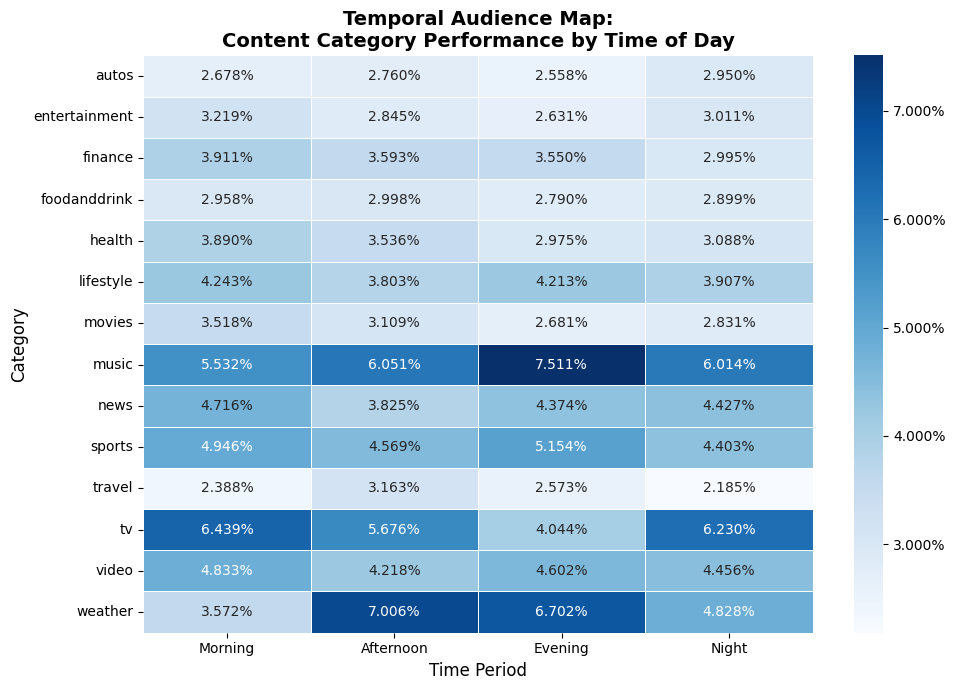

Saved: temporal_audience_map.png


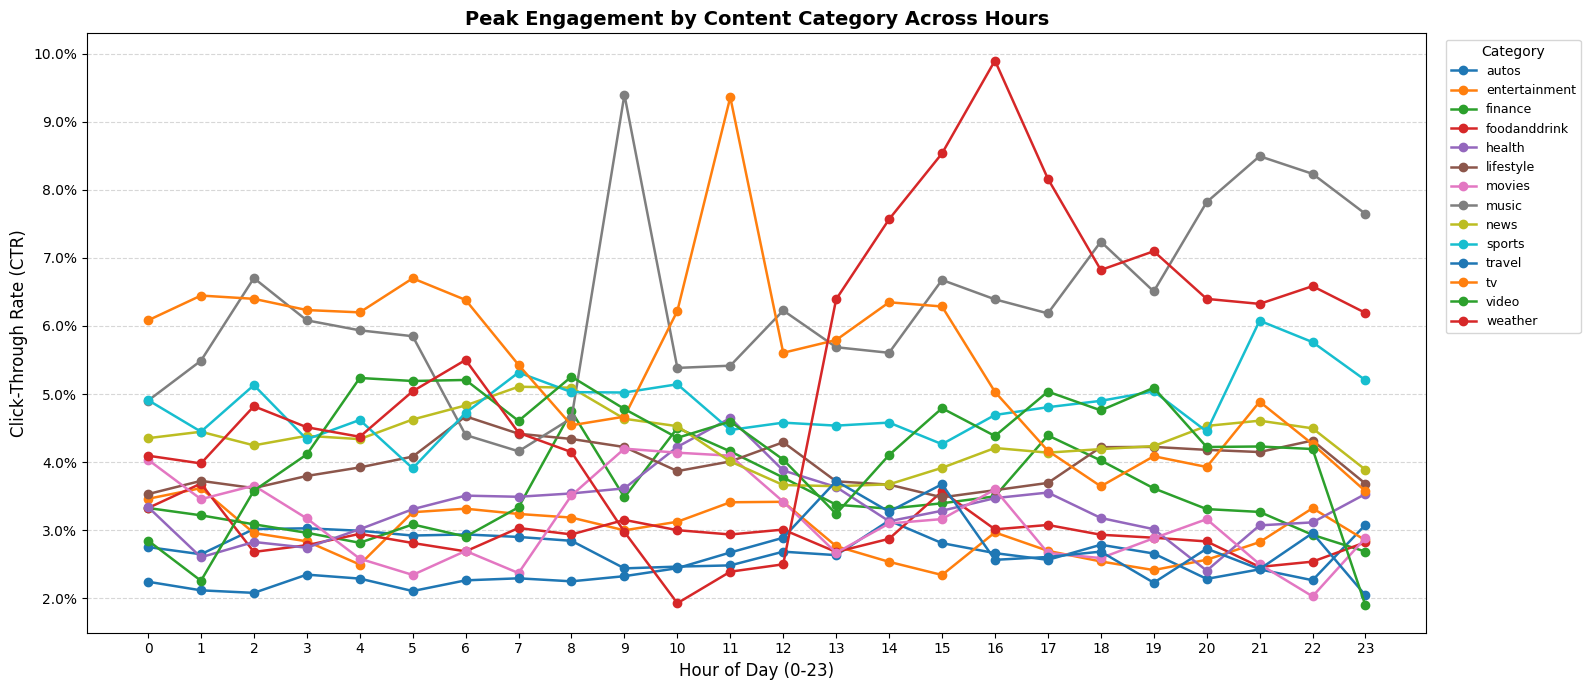

Saved: peak_engagement_by_category.png


In [10]:
# ============================================================
# SECTION 6: TEMPORAL AUDIENCE MAPS
# ============================================================

# --- Audience Map: Which categories perform best at each time period ---
audience_map = cat_period_pivot.copy()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    audience_map,
    annot=True,
    fmt='.3%',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'format': mtick.PercentFormatter(xmax=1.0, decimals=3)}
)
ax.set_title('Temporal Audience Map:\nContent Category Performance by Time of Day',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig(f'{output_dir}/temporal_audience_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: temporal_audience_map.png")

# --- Peak Engagement: Line chart per category across hours ---
fig, ax = plt.subplots(figsize=(16, 7))
categories = df['category'].unique()
palette = sns.color_palette('tab10', len(categories))

for i, cat in enumerate(sorted(categories)):
    cat_data = cat_hour_ctr[cat_hour_ctr['category'] == cat]
    ax.plot(cat_data['hour'], cat_data['ctr'], marker='o', label=cat,
            color=palette[i], linewidth=1.8)

ax.set_xlabel('Hour of Day (0-23)', fontsize=12)
ax.set_ylabel('Click-Through Rate (CTR)', fontsize=12)
ax.set_title('Peak Engagement by Content Category Across Hours', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax= 1.0, decimals=1))
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{output_dir}/peak_engagement_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: peak_engagement_by_category.png")



In [11]:
# ============================================================
# SECTION 7: OUTPUTS
# ============================================================

# Export tables
hourly_ctr.to_csv(f'{output_dir}/hourly_ctr.csv', index=False)
period_ctr.to_csv(f'{output_dir}/period_ctr.csv', index=False)
ranked_engagement.to_csv(f'{output_dir}/category_time_engagement.csv', index=False)
optimal_windows.to_csv(f'{output_dir}/optimal_publishing_windows.csv', index=False)

# ============================================================
# SECTION 8: KEY SUMMARY INSIGHTS
# ============================================================

print("\n" + "="*60)
print("KEY SUMMARY INSIGHTS")
print("="*60)

peak_hour = hourly_ctr.loc[hourly_ctr['ctr'].idxmax()]
low_hour  = hourly_ctr.loc[hourly_ctr['ctr'].idxmin()]
print(f"\n[1] Peak engagement hour:   {int(peak_hour['hour']):02d}:00  (CTR = {peak_hour['ctr']:.3%})")
print(f"[2] Lowest engagement hour: {int(low_hour['hour']):02d}:00  (CTR = {low_hour['ctr']:.3%})")

best_period_row  = period_ctr.loc[period_ctr['ctr'].idxmax()]
worst_period_row = period_ctr.loc[period_ctr['ctr'].idxmin()]
print(f"\n[3] Best time period:   {best_period_row['time_period']}  (CTR = {best_period_row['ctr']:.3%})")
print(f"[4] Lowest time period: {worst_period_row['time_period']}  (CTR = {worst_period_row['ctr']:.3%})")

best_cat  = optimal_windows.iloc[0]
print(f"\n[5] Highest CTR category:  {best_cat['category']} "
      f"(Best hour: {int(best_cat['best_hour']):02d}:00, "
      f"Best period: {best_cat['best_time_period']}, "
      f"CTR: {best_cat['best_hour_ctr']:.3%})")

print("\n[6] Optimal Publishing Windows:")
for _, row in optimal_windows.iterrows():
    print(f"    {row['category']:<20} | Hour: {int(row['best_hour']):02d}:00 | "
          f"Period: {row['best_time_period']:<10} | CTR: {row['best_hour_ctr']:.3%}")

print("\n" + "="*60)
print("All outputs saved to Google Drive:")
print(f"  {output_dir}")
print("="*60)
print("Files saved:")
print("  - hourly_ctr_trend.png")
print("  - ctr_by_time_period.png")
print("  - heatmap_category_hour.png")
print("  - heatmap_category_time_period.png")
print("  - temporal_audience_map.png")
print("  - peak_engagement_by_category.png")
print("  - hourly_ctr.csv")
print("  - period_ctr.csv")
print("  - category_time_engagement.csv")
print("  - optimal_publishing_windows.csv")


KEY SUMMARY INSIGHTS

[1] Peak engagement hour:   08:00  (CTR = 4.291%)
[2] Lowest engagement hour: 13:00  (CTR = 3.802%)

[3] Best time period:   Morning  (CTR = 4.202%)
[4] Lowest time period: Afternoon  (CTR = 3.899%)

[5] Highest CTR category:  weather (Best hour: 16:00, Best period: Afternoon, CTR: 9.898%)

[6] Optimal Publishing Windows:
    weather              | Hour: 16:00 | Period: Afternoon  | CTR: 9.898%
    music                | Hour: 09:00 | Period: Evening    | CTR: 9.397%
    tv                   | Hour: 11:00 | Period: Morning    | CTR: 9.360%
    sports               | Hour: 21:00 | Period: Evening    | CTR: 6.078%
    video                | Hour: 08:00 | Period: Morning    | CTR: 5.256%
    news                 | Hour: 07:00 | Period: Morning    | CTR: 5.108%
    finance              | Hour: 08:00 | Period: Morning    | CTR: 4.748%
    lifestyle            | Hour: 06:00 | Period: Morning    | CTR: 4.672%
    health               | Hour: 11:00 | Period: Morning    |